<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 4.06e-04 | train loss 0.9225 acc 0.613 | val loss 0.5297 acc 0.769 *


[ResNet-50] Epoch   2/100 | LR: 4.06e-04 | train loss 0.7330 acc 0.724 | val loss 0.6500 acc 0.684


[ResNet-50] Epoch   3/100 | LR: 4.06e-04 | train loss 0.6780 acc 0.726 | val loss 0.6255 acc 0.719


[ResNet-50] Epoch   4/100 | LR: 4.06e-04 | train loss 0.6254 acc 0.741 | val loss 0.5161 acc 0.797 *


...

[ResNet-50] Epoch  18/100 | LR: 4.06e-04 | train loss 0.2313 acc 0.919 | val loss 0.5080 acc 0.853


[ResNet-50] Epoch  19/100 | LR: 4.06e-04 | train loss 0.2221 acc 0.927 | val loss 0.6446 acc 0.784


[ResNet-50] Epoch  20/100 | LR: 4.06e-04 | train loss 0.1965 acc 0.931 | val loss 0.5980 acc 0.847


[ResNet-50] Epoch  21/100 | LR: 4.06e-04 | train loss 0.2068 acc 0.920 | val loss 0.6504 acc 0.803


[ResNet-50] Epoch  22/100 | LR: 4.06e-04 | train loss 0.2330 acc 0.934 | val loss 0.4994 acc 0.844

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 22.

[ResNet-50] Restored best checkpoint (val loss = 0.3972)


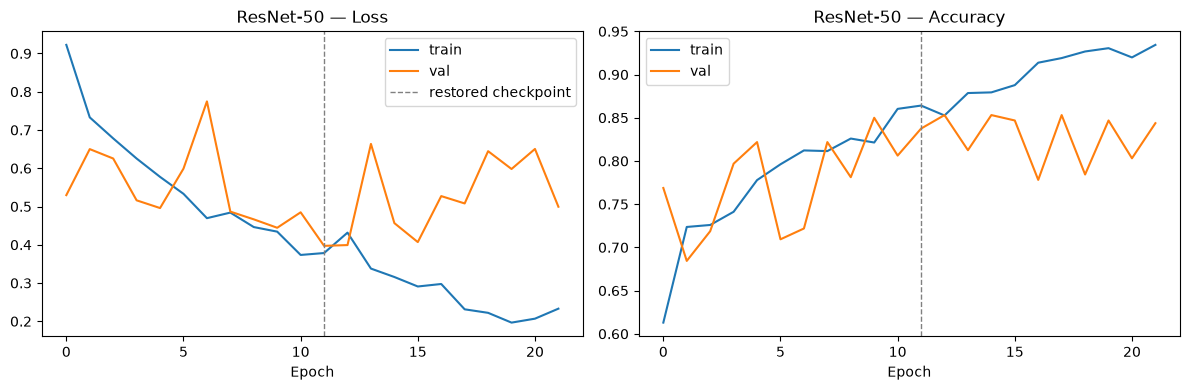

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.496


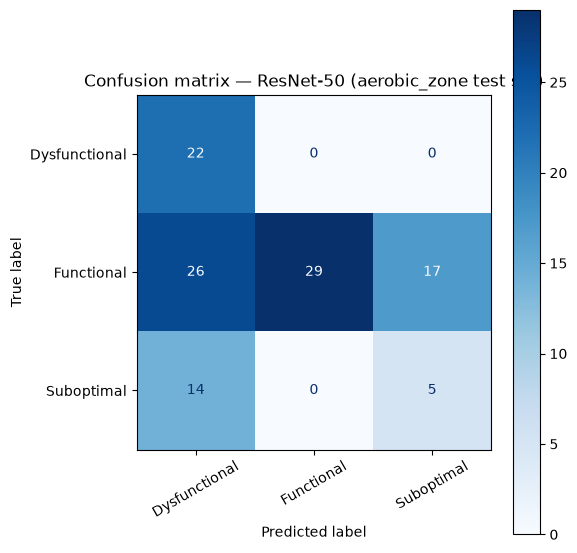

               precision    recall  f1-score   support

Dysfunctional      0.355     1.000     0.524        22
   Functional      1.000     0.403     0.574        72
   Suboptimal      0.227     0.263     0.244        19

     accuracy                          0.496       113
    macro avg      0.527     0.555     0.447       113
 weighted avg      0.744     0.496     0.509       113



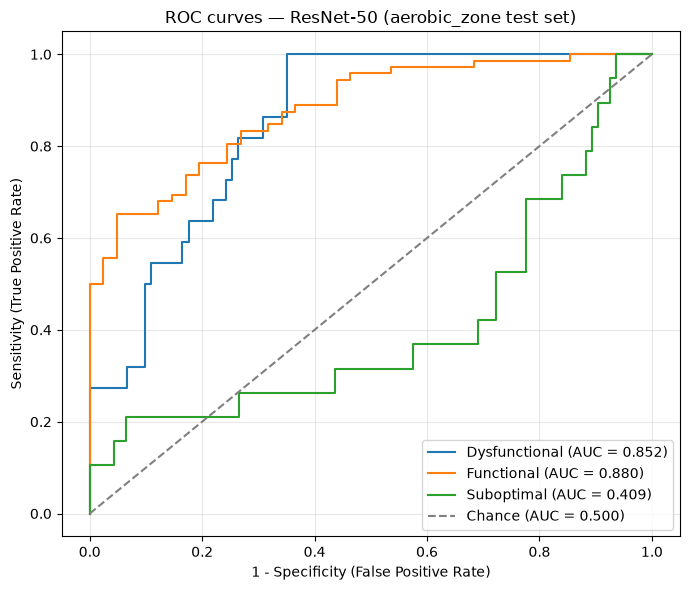

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.852
  Functional     : 0.880
  Suboptimal     : 0.409

Mean AUC (over 3/3 classes with test examples): 0.714


(np.float64(0.49557522123893805),
 {'Dysfunctional': 0.852147852147852,
  'Functional': 0.8797425474254742,
  'Suboptimal': 0.40873460246360577})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet50_Atlantis.pkl
Saved model weights to ../models/aerobic_zone_resnet50_cnn.pt
